<a href="https://colab.research.google.com/github/priyansh-commits/practice/blob/main/Task_PCA.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

### `Task` How dimensionality reduction using Principal Component Analysis (PCA) on the Wine Quality dataset contributes to improving the classification accuracy and efficiency of wine type.

Note : Use KNN for Classification.

Data Link :  [Wine Data](https://docs.google.com/spreadsheets/d/e/2PACX-1vQDVwxneOKOaJL13QMhkAhYrgWlH1tICY7RacUnj_lL8m9uUWaaUf3p7bScNyh_D2Rvt7nc1q11adSy/pub?gid=647503637&single=true&output=csv)

In [32]:
# Data Loading
import pandas as pd
wine_data_path = "https://docs.google.com/spreadsheets/d/e/2PACX-1vQDVwxneOKOaJL13QMhkAhYrgWlH1tICY7RacUnj_lL8m9uUWaaUf3p7bScNyh_D2Rvt7nc1q11adSy/pub?gid=647503637&single=true&output=csv"
wine = pd.read_csv(wine_data_path)
wine.head(1)

,type,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality
0,white,7.0,0.27,0.36,20.7,0.045,45.0,170.0,1.001,3.0,0.45,8.8,6


In [33]:
wine.isnull().sum()

,0
type,0
fixed acidity,10
volatile acidity,8
citric acid,3
residual sugar,2
chlorides,2
free sulfur dioxide,0
total sulfur dioxide,0
density,0
pH,9


In [34]:
from numpy._core import numeric

for i in wine.columns[1:]:
    wine[i].fillna(wine[i].mean(), inplace=True)
# wine.head(1
wine.isnull().sum()
wine.shape
wine=wine.drop_duplicates()
wine.shape

/tmp/ipykernel_488/2473379339.py:4: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  wine[i].fillna(wine[i].mean(), inplace=True)


(5329, 13)

In [35]:
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()
wine['type'] = le.fit_transform(wine['type'])
wine.sample(5)
from sklearn.model_selection import train_test_split
X = wine.drop('type', axis=1)
y = wine['type']
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=21)
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score
knn = KNeighborsClassifier()
knn.fit(X_train, y_train)
y_pred = knn.predict(X_test)
accuracy = accuracy_score(y_test, y_pred)
print("Accuracy:", accuracy)
from sklearn.model_selection import cross_val_score
scores = cross_val_score(knn,X_test ,y_test,  cv=5)
scores

print("Accuracy: %0.2f (+/- %0.2f)" % (scores.mean(), scores.std() * 2))



Accuracy: 0.9906191369606003
Accuracy: 0.99 (+/- 0.02)


In [42]:
from sklearn.decomposition import PCA
for i in range(1,13):
  pca = PCA(n_components=i)

  X_train_pca = pca.fit_transform(X_train)
  X_test_pca = pca.transform(X_test)
  knn = KNeighborsClassifier()
  knn.fit(X_train_pca, y_train)
  y_pred = knn.predict(X_test_pca)
  accuracy = accuracy_score(y_test, y_pred)
  print("Accuracy:",i,'->', round(accuracy*100,2))

Accuracy: 1 -> 97.56
Accuracy: 2 -> 97.94
Accuracy: 3 -> 97.94
Accuracy: 4 -> 98.59
Accuracy: 5 -> 98.97
Accuracy: 6 -> 98.5
Accuracy: 7 -> 98.78
Accuracy: 8 -> 98.78
Accuracy: 9 -> 98.78
Accuracy: 10 -> 98.78
Accuracy: 11 -> 99.06
Accuracy: 12 -> 99.06


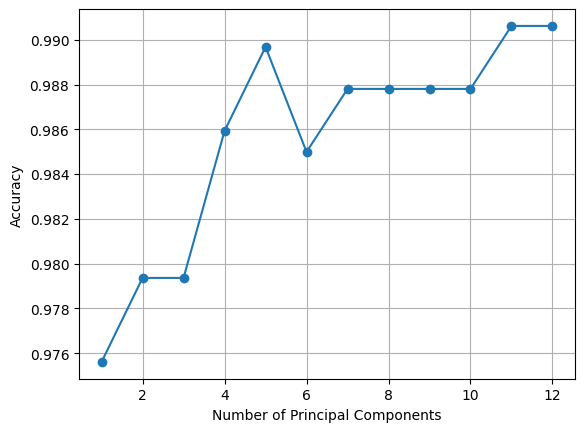

In [37]:
import matplotlib.pyplot as plt

acc = []

for i in range(1,13):
    pca = PCA(n_components=i)

    X_train_pca = pca.fit_transform(X_train)
    X_test_pca = pca.transform(X_test)

    knn = KNeighborsClassifier()
    knn.fit(X_train_pca, y_train)

    y_pred = knn.predict(X_test_pca)

    acc.append(accuracy_score(y_test,y_pred))

plt.plot(range(1,13),acc,marker='o')
plt.xlabel("Number of Principal Components")
plt.ylabel("Accuracy")
plt.grid(True)
plt.show()

In [46]:
from sklearn.decomposition import PCA
import pandas as pd

pca = PCA(n_components=7)

X_train_pca = pca.fit_transform(X_train)
X_test_pca = pca.transform(X_test)

X_train_new = pd.DataFrame(
    X_train_pca,
    columns=[f'PC{i}' for i in range(1,8)]
)

X_train_new.head()

,PC1,PC2,PC3,PC4,PC5,PC6,PC7
0,1.483767,1.975199,-3.510402,-0.518661,-2.197803,1.491492,-0.253365
1,0.133043,0.415414,-0.457850,-0.500797,-0.233683,0.159731,0.862773
2,-0.208684,-2.775062,1.272163,1.339336,-0.801642,0.089220,-1.042092
3,-1.035568,0.652779,-2.432497,-0.611848,-0.285918,-1.752578,-0.026070
4,1.870826,-0.953575,-0.297677,-0.305240,0.585551,-0.216617,0.205605


In [49]:
knn = KNeighborsClassifier()
knn.fit(X_train_new, y_train)

X_test_pca = pca.transform(X_test)
X_test_new = pd.DataFrame(
    X_test_pca,
    columns=[f'PC{i}' for i in range(1,8)]
)

y_pred = knn.predict(X_test_new)
accuracy = accuracy_score(y_test, y_pred)
print("Accuracy:", round(accuracy,2)*100)
print('after transformation ',X_train_new.shape)
print('before transformation ',X_train.shape)

Accuracy: 99.0
after transformation  (4263, 7)
before transformation  (4263, 12)
